Load packages

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data loading

In [2]:
# Data path
main_df = pd.read_csv(r"Data/Suppl_Figure_Timecourse_Data.csv")

Data processing

Adjust time column

In [3]:
main_df["Time (h)"] = main_df["Time"].str.replace("h", "").astype(int)

Remove outliers by Batch and Category

Adjust data categories for more coherent plotting

In [4]:
main_df["Condition"] = main_df["Condition"].replace({
    "LPS/Unactivated": "LPS",
    "Unprimed/Unactivated": "Untreated",
    "Unprimed/Nigericin": "Nigericin"
})

Define Untreated as starting point for each condition

In [5]:
# 1) Subset Untreated rows
untreated_df = main_df[main_df["Condition"] == "Untreated"].copy()

# Safety: ensure Time (h) is 0 (if you want to enforce it)
# If Untreated truly always has 0, you can skip this line.
# untreated_df["Time (h)"] = 0

# 2) Decide target conditions: all except 'Untreated'
all_conditions = pd.Index(main_df["Condition"].unique())
target_conditions = [c for c in all_conditions if c != "Untreated"]

# 3) Prepare a version of Untreated rows where we clean metadata if desired
#    Set non-numeric, non-key columns to NA to avoid leaking Untreated's well/plate/etc. into other conditions.
key_cols = {"Condition", "Time (h)"}
num_cols = set(main_df.select_dtypes(include="number").columns)
meta_cols_to_clear = [c for c in main_df.columns if c not in key_cols and c not in num_cols]

untreated_for_clone = untreated_df.copy()
for col in meta_cols_to_clear:
    untreated_for_clone[col] = pd.NA

# 4) Build cloned rows for each target condition
cloned_blocks = []
for cond in target_conditions:
    block = untreated_for_clone.copy()
    block["Condition"] = cond
    cloned_blocks.append(block)

# If there are no other conditions, this will just not add anything
cloned_df = pd.concat(cloned_blocks, ignore_index=True) if cloned_blocks else pd.DataFrame(columns=main_df.columns)

# 5) Ensure columns align and append to the original dataframe
#    (If main_df has columns that cloned_df might miss, add them as NA)
for col in main_df.columns:
    if col not in cloned_df.columns:
        cloned_df[col] = pd.NA
cloned_df = cloned_df[main_df.columns]

main_df_with_baseline = pd.concat([cloned_df, main_df], ignore_index=True)

# Delete "Untreated" condition to prevent double plotting
main_df_with_baseline = main_df_with_baseline[main_df_with_baseline["Condition"] != "Untreated"]

Plot settings

In [6]:
# What to plot?
x = 'Time (h)'
y = 'Cytoplasm_AreaShape_Area_CD45' # number_ASC, Cytoplasm_Intensity_MeanIntensity_NFKB, area_ASC, Membrane_AreaShape_Area_Nuclei, Cytoplasm_AreaShape_Area_CD45, Cytoplasm_Shape_MAX_RADIUS, Nuclei_Intensity_SumIntensity_NFKB
ytitle = y
order = ['Untreated', 
         'LPS', 
         'Nigericin', 
         'LPS/Nigericin'
         ]
hue = 'Condition'

# Set colors
# Define a dictionary that maps categories to colors
color_dict = {
    'Untreated': 'gray', 
    'LPS': 'orange', 
    'Nigericin': 'red', 
    'LPS/Nigericin': 'purple'
    }

# Set the context to 'talk'
sns.set_context('talk')
# Arial font
plt.rcParams["font.family"] = "Arial"

# Show all columns
df_columns = main_df_with_baseline.columns.to_list()

Plot data per Batch

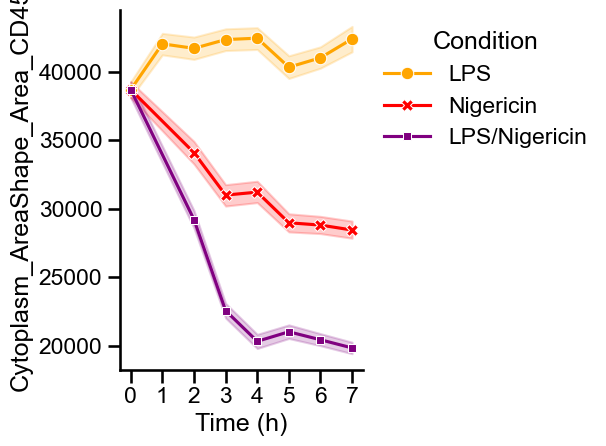

In [7]:
# Lineplot
ax = sns.lineplot(data=main_df_with_baseline, x=x, y=y, hue=hue, style=hue, markers=True, dashes=False, palette=color_dict)

# Figure aesthetics
plt.xticks(range(8))
ax.set(xlabel=x)
ax.set(ylabel=y)
sns.despine(ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), frameon=False)

# Show and save the figure
plt.tight_layout()

# Saving plot
plt.savefig(y + '.pdf', bbox_inches='tight')

plt.show()
